# Customer Churn Prediction using Machine Learning

## Project Overview

This project builds a machine learning model to predict customer churn for a telecom company. The objective is to identify customers at risk of leaving so that the business can take proactive retention actions.

The project includes exploratory data analysis, feature engineering, model comparison, threshold optimization, and interpretation of the factors associated with churn.

## 1. Import Libraries

In [91]:
import pandas as pd

## 2. Load Dataset

In [92]:
df = pd.read_csv('telco_churn_cleaned.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [93]:
df.shape

(7043, 21)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [95]:
ml_df = df.drop("customerID", axis=1).copy()

In [96]:
ml_df.shape

(7043, 20)

## 3. Exploratory Data Analysis

### Churn Distribution

In [97]:
ml_df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [98]:
ml_df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


### Churn by Contract

In [99]:
id="k1w8n9"
pd.crosstab(
    ml_df["Contract"],
    ml_df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Churn by Internet Service

In [100]:
id="xq4k2m"
pd.crosstab(
    ml_df["InternetService"],
    ml_df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### Churn by Payment Method

In [101]:
id="m3j7pa"
pd.crosstab(
    ml_df["PaymentMethod"],
    ml_df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### Numerical Feature Analysis

In [102]:
ml_df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [103]:
ml_df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


## 4. Feature Engineering

In [104]:
ml_df["AvgMonthlySpend"] = (
    ml_df["TotalCharges"] / ml_df["tenure"].replace(0, float("nan"))
)

In [105]:
ml_df[["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend"]].head()

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000


In [106]:
ml_df[ml_df["tenure"] == 0][
    ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend"]
]

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
488,0,52.55,0.0,NaN
753,0,20.25,0.0,NaN
936,0,80.85,0.0,NaN
1082,0,25.75,0.0,NaN
1340,0,56.05,0.0,NaN
3331,0,19.85,0.0,NaN
3826,0,25.35,0.0,NaN
4380,0,20.00,0.0,NaN
5218,0,19.70,0.0,NaN
6670,0,73.35,0.0,NaN


In [107]:
ml_df[ml_df["tenure"] == 0][
    ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend"]
]

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
488,0,52.55,0.0,NaN
753,0,20.25,0.0,NaN
936,0,80.85,0.0,NaN
1082,0,25.75,0.0,NaN
1340,0,56.05,0.0,NaN
3331,0,19.85,0.0,NaN
3826,0,25.35,0.0,NaN
4380,0,20.00,0.0,NaN
5218,0,19.70,0.0,NaN
6670,0,73.35,0.0,NaN


## 5. Prepare Features and Target

In [108]:
X = ml_df.drop("Churn", axis=1)
y = ml_df["Churn"]

In [109]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 20)
y shape: (7043,)


In [110]:
y.value_counts()

,count
Churn,
No,5174
Yes,1869


## 6. Train-Test Split

In [111]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [112]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 20)
X_test: (1409, 20)
y_train: (5634,)
y_test: (1409,)


## 7. Data Preprocessing

In [113]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [114]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [115]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [116]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [117]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 8. Logistic Regression — Baseline

In [118]:
y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

In [119]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [120]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AvgMonthlySpend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [121]:
y_pred = logistic_model.predict(X_test)

In [122]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8055358410220014


In [123]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [124]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [165 209]]


## 9. Random Forest

In [125]:
from sklearn.ensemble import RandomForestClassifier

In [126]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [127]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AvgMonthlySpend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [128]:
rf_pred = random_forest_model.predict(X_test)

In [129]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7849538679914834


In [130]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



## 10. Model Comparison

In [131]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.8055, 0.7850],
    "Churn Precision": [0.66, 0.62],
    "Churn Recall": [0.56, 0.48],
    "Churn F1": [0.60, 0.54]
})

model_comparison

,Model,Accuracy,Churn Precision,Churn Recall,Churn F1
0,Logistic Regression,0.8055,0.66,0.56,0.60
1,Random Forest,0.7850,0.62,0.48,0.54


## 11. Hyperparameter Tuning

In [132]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    logistic_model,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [133]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges',
                                                                          'AvgMonthlySpend']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('oneho...
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1, param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100]},
             scoring='f1')

In [134]:
print("Best C:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Best C: {'classifier__C': 1}
Best CV F1: 0.5987859656114629


In [135]:
tuned_pred = grid_search.predict(X_test)

In [136]:
print("Tuned Logistic Regression Accuracy:",
      accuracy_score(y_test, tuned_pred))

Tuned Logistic Regression Accuracy: 0.8055358410220014


In [137]:
print(classification_report(y_test, tuned_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 12. ROC-AUC Evaluation

In [138]:
y_proba = grid_search.predict_proba(X_test)[:, 1]

In [139]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8422304890335581


## 13. Threshold Optimization

In [140]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

for threshold in thresholds:
    y_threshold = (y_proba >= threshold).astype(int)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision_score(y_test, y_threshold):.2f} | "
        f"Recall: {recall_score(y_test, y_threshold):.2f} | "
        f"F1: {f1_score(y_test, y_threshold):.2f}"
    )

Threshold: 0.3 | Precision: 0.52 | Recall: 0.76 | F1: 0.62
Threshold: 0.35 | Precision: 0.54 | Recall: 0.71 | F1: 0.61
Threshold: 0.4 | Precision: 0.57 | Recall: 0.67 | F1: 0.61
Threshold: 0.45 | Precision: 0.60 | Recall: 0.62 | F1: 0.61
Threshold: 0.5 | Precision: 0.66 | Recall: 0.56 | F1: 0.60


In [141]:
final_threshold = 0.30

final_pred = (y_proba >= final_threshold).astype(int)

In [142]:
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [143]:
from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(y_test, final_pred)

print(cm_final)

[[774 261]
 [ 91 283]]


## 14. Model Interpretation

In [144]:
feature_names = grid_search.best_estimator_["preprocessor"].get_feature_names_out()

print(len(feature_names))

46


In [145]:
coefficients = grid_search.best_estimator_["classifier"].coef_[0]

In [146]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [147]:
feature_importance.sort_values(
    "Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient
17,cat__InternetService_Fiber optic,0.626079
37,cat__Contract_Month-to-month,0.582088
3,num__TotalCharges,0.550740
44,cat__PaymentMethod_Electronic check,0.200641
33,cat__StreamingTV_Yes,0.198269
36,cat__StreamingMovies_Yes,0.198150
19,cat__OnlineSecurity_No,0.159842
28,cat__TechSupport_No,0.134662
15,cat__MultipleLines_Yes,0.102359
0,num__SeniorCitizen,0.054237


In [148]:
feature_importance.sort_values(
    "Coefficient",
    ascending=True
).head(15)

,Feature,Coefficient
1,num__tenure,-1.272636
39,cat__Contract_Two year,-0.769680
16,cat__InternetService_DSL,-0.638184
2,num__MonthlyCharges,-0.588163
40,cat__PaperlessBilling_No,-0.338180
23,cat__OnlineBackup_No internet service,-0.292793
20,cat__OnlineSecurity_No internet service,-0.292793
26,cat__DeviceProtection_No internet service,-0.292793
32,cat__StreamingTV_No internet service,-0.292793
35,cat__StreamingMovies_No internet service,-0.292793


## 15. Final Model Evaluation

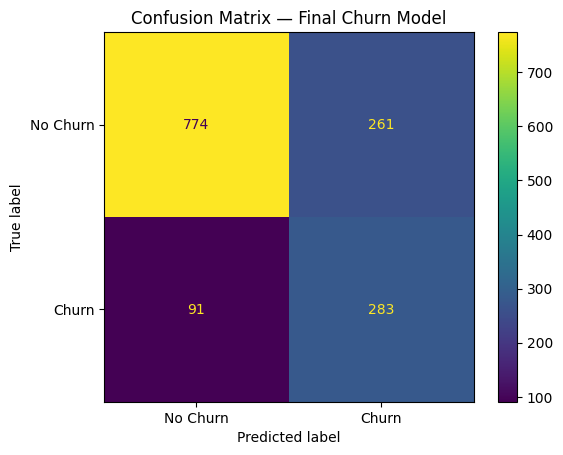

In [149]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    display_labels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix — Final Churn Model")
plt.show()

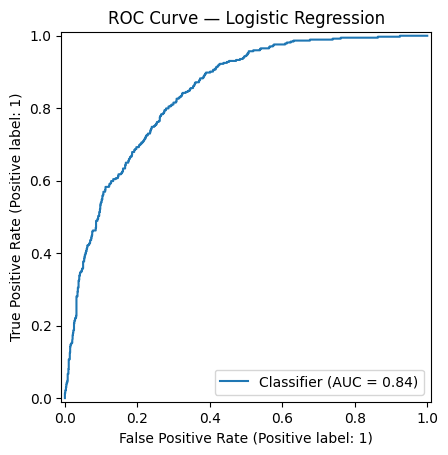

In [150]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_proba
)

plt.title("ROC Curve — Logistic Regression")
plt.show()

## 16. Business Insights

- Month-to-month contract customers showed a strong association with higher churn risk.
- Fiber optic internet customers showed a higher churn association compared with the reference category.
- Customers with longer tenure were strongly associated with lower churn risk.
- Two-year contract customers showed a strong association with lower churn.
- Electronic check payment was associated with higher churn risk.
- Customers without online security and technical support showed higher churn associations.
- Automatic credit-card payment and having dependents were associated with lower churn.

## 17. Business Recommendations

- Encourage month-to-month customers to move to longer-term contracts through targeted offers.
- Focus retention efforts on newer customers who have shorter tenure.
- Investigate service quality, pricing, and support issues among fiber optic customers.
- Provide targeted support or security bundles to customers without these services.
- Consider proactive engagement with customers using electronic check payments.
- Use the churn model to prioritize high-risk customers for retention campaigns.

## 18. Conclusion

This project developed a machine learning model to predict customer churn using the Telco Customer Churn dataset. The workflow included exploratory data analysis, feature engineering, preprocessing, Logistic Regression, Random Forest, and hyperparameter tuning.

Logistic Regression performed better than Random Forest, achieving an accuracy of approximately **80.55%** and an **ROC-AUC of 0.842**. After threshold optimization, the classification threshold was reduced from 0.50 to **0.30**, increasing churn recall from **56% to 76%** and allowing the model to identify **283 out of 374 actual churners**.

The model interpretation highlighted several churn-related patterns, including month-to-month contracts, fiber optic service, electronic check payments, and shorter tenure. These insights can help a telecom company prioritize high-risk customers and develop targeted retention strategies.

Overall, the project demonstrates how machine learning can be combined with business analysis to identify customers at risk of churn and support data-driven customer retention decisions.
